# Student Dropout Intelligence System

**Goal (2 hours):** Use the **same dataset** to answer **three different questions**:

1) **K-Means** → *What types of students exist?* (no labels)  
2) **Logistic Regression** → *Who might drop out?* (explainable probability)  
3) **Random Forest** → *Who might drop out in messy reality?* (stronger patterns)

> Remember: **Models don’t compete. Questions compete.**


## 1) Import libraries (why?)

- **pandas/numpy** → data handling
- **scikit-learn** → ML models
- **matplotlib/seaborn** → simple visuals

If a library is missing, install it using:
`pip install pandas numpy scikit-learn matplotlib seaborn`


In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


## 2) Load the dataset (why?)

- We load **student_data.csv** from the same folder.
- Each row is **one student**.
- Each column is a **behavior signal** from the first week.


In [2]:
df = pd.read_csv("student_data.csv")
df.head()


,student_id,attendance_rate,assignment_submitted,avg_quiz_score,coding_minutes,doubts_asked,late_submissions,project_commit_count,peer_messages_sent,video_watched_percent,background,dropout
0,1,0.95,1,82,120,6,0,8,12,90,2,0
1,2,0.40,0,35,20,0,4,1,0,25,0,1
2,3,0.60,1,70,240,1,1,18,2,60,1,0
3,4,0.85,1,78,100,10,0,6,30,92,1,0
4,5,0.30,0,28,15,0,5,0,0,18,0,1


## 3) Quick scan (why?)

We check:
- column names and types
- whether data looks reasonable
- basic statistics (min/max/average)

This is how engineers avoid surprises later.


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             40 non-null     int64  
 1   attendance_rate        40 non-null     float64
 2   assignment_submitted   40 non-null     int64  
 3   avg_quiz_score         40 non-null     int64  
 4   coding_minutes         40 non-null     int64  
 5   doubts_asked           40 non-null     int64  
 6   late_submissions       40 non-null     int64  
 7   project_commit_count   40 non-null     int64  
 8   peer_messages_sent     40 non-null     int64  
 9   video_watched_percent  40 non-null     int64  
 10  background             40 non-null     int64  
 11  dropout                40 non-null     int64  
dtypes: float64(1), int64(11)
memory usage: 3.9 KB


In [4]:
df.describe()


,student_id,attendance_rate,assignment_submitted,avg_quiz_score,coding_minutes,doubts_asked,late_submissions,project_commit_count,peer_messages_sent,video_watched_percent,background,dropout
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,20.500000,0.625500,0.700000,60.175000,118.125000,3.175000,1.750000,8.275000,6.750000,64.300000,0.950000,0.300000
std,11.690452,0.222929,0.464095,22.657865,77.834534,2.772461,1.918199,6.868686,7.037446,28.355075,0.749359,0.464095
min,1.000000,0.250000,0.000000,18.000000,10.000000,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000
25%,10.750000,0.435000,0.000000,39.500000,33.750000,1.000000,0.000000,1.750000,1.000000,38.750000,0.000000,0.000000
50%,20.500000,0.610000,1.000000,64.500000,115.000000,2.500000,1.000000,7.500000,5.000000,71.000000,1.000000,0.000000
75%,30.250000,0.827500,1.000000,78.000000,180.000000,5.000000,3.000000,13.250000,10.250000,89.250000,1.250000,1.000000
max,40.000000,0.980000,1.000000,92.000000,260.000000,10.000000,6.000000,22.000000,30.000000,99.000000,2.000000,1.000000


## 4) Define the feature set (why?)

We choose only the **input signals** we want the models to learn from.
We keep the `dropout` column separate because it's the *outcome label* (used only for supervised learning).


In [5]:
features = [
    "attendance_rate",
    "assignment_submitted",
    "avg_quiz_score",
    "coding_minutes",
    "doubts_asked",
    "late_submissions",
    "project_commit_count",
    "peer_messages_sent",
    "video_watched_percent",
    "background"
]


## 5) Standardize features (why?)

K-Means uses **distance**.  
If one column has large values (like `coding_minutes`) it can dominate the result.

So we scale all features to the same level (mean 0, std 1).


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])


# PART A — K-Means (Discovery)

## 6) Run K-Means (why?)

K-Means answers:
> **“What types of students exist?”**

No dropout labels needed.  
It groups students by similarity of behavior.


In [7]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()


cluster
1    15
0    12
2     7
3     6
Name: count, dtype: int64

## 7) Understand each cluster (why?)

This is the **WOW moment**.

We take the average behavior inside each cluster.
Then we *name* the clusters like personas:
- Silent grinders
- Social learners
- At-risk drifters
- Consistent performers


In [8]:
cluster_profile = df.groupby("cluster")[features].mean()
cluster_profile


,attendance_rate,assignment_submitted,avg_quiz_score,coding_minutes,doubts_asked,late_submissions,project_commit_count,peer_messages_sent,video_watched_percent,background
cluster,,,,,,,,,,
0,0.357500,0.0,30.666667,22.916667,0.250000,4.333333,0.750000,0.250000,25.750000,0.000000
1,0.868667,1.0,82.800000,171.000000,4.933333,0.000000,13.066667,11.933333,91.733333,1.600000
2,0.645714,1.0,66.428571,190.714286,2.000000,1.000000,14.142857,3.285714,71.428571,1.142857
3,0.530000,1.0,55.333333,91.666667,6.000000,1.833333,4.500000,10.833333,64.500000,1.000000


### Optional: quick visual (why?)

This makes it easier to “see” differences between clusters.


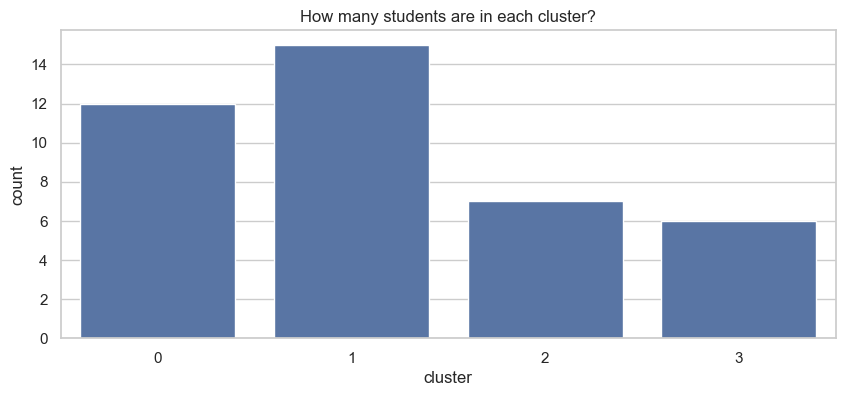

In [9]:
plt.figure(figsize=(10,4))
sns.countplot(data=df, x="cluster")
plt.title("How many students are in each cluster?")
plt.show()


# PART B — Logistic Regression (Explainable Risk)

## 8) Train/test split (why?)

We split the data:
- **train** → model learns patterns
- **test** → model is checked on unseen rows

This prevents “memorizing”.


In [10]:
X = df[features]
y = df["dropout"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 9) Train Logistic Regression (why?)

Logistic Regression answers:
> **“Will student X drop out?”** (with a probability)

It’s great when we want:
- fast baseline
- explainable reasoning (weights)


In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

df["dropout_risk_lr"] = lr.predict_proba(X)[:, 1]
df[["student_id", "dropout_risk_lr"]].head(10)


,student_id,dropout_risk_lr
0,1,6.909789e-08
1,2,9.999923e-01
2,3,3.231448e-17
3,4,2.391635e-06
4,5,9.999989e-01
5,6,2.990029e-12
6,7,9.582209e-04
7,8,3.544153e-09
8,9,9.993085e-01
9,10,8.883798e-21


## 10) Explain 'why' using coefficients (why?)

Coefficients show which signals push risk up or down.

- positive → increases dropout risk  
- negative → reduces dropout risk


In [12]:
lr_weights = pd.Series(lr.coef_[0], index=features).sort_values()
lr_weights


coding_minutes          -0.205151
video_watched_percent   -0.074157
avg_quiz_score          -0.050198
peer_messages_sent      -0.031648
doubts_asked            -0.016124
project_commit_count    -0.009703
background              -0.003428
assignment_submitted    -0.003284
attendance_rate         -0.000364
late_submissions         0.004147
dtype: float64

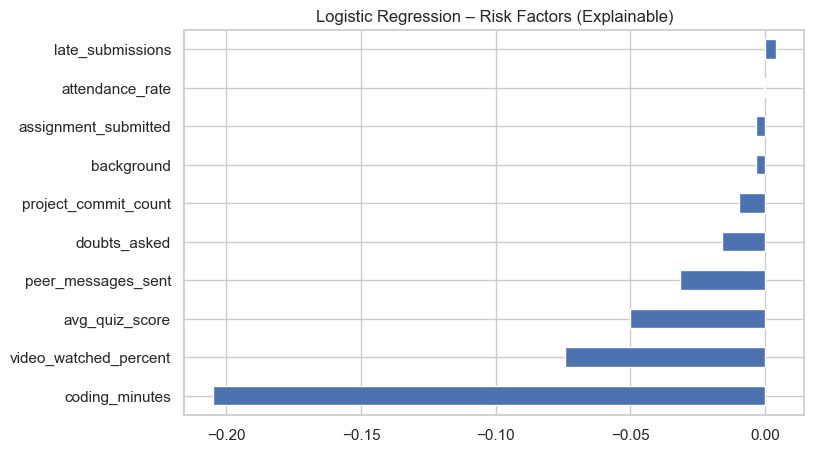

In [13]:
plt.figure(figsize=(8,5))
lr_weights.plot(kind="barh")
plt.title("Logistic Regression – Risk Factors (Explainable)")
plt.show()


# PART C — Random Forest (Messy Reality)

## 11) Train Random Forest (why?)

Random Forest answers the same question as Logistic Regression:
> “Will student X drop out?”

But it is better when:
- patterns are non-linear
- human behavior is inconsistent
- you want stronger performance


In [14]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

df["dropout_risk_rf"] = rf.predict_proba(X)[:, 1]
df[["student_id", "dropout_risk_rf"]].head(10)


,student_id,dropout_risk_rf
0,1,0.000
1,2,1.000
2,3,0.055
3,4,0.000
4,5,1.000
5,6,0.000
6,7,0.000
7,8,0.000
8,9,0.990
9,10,0.000


## 12) Feature importance (why?)

Random Forest doesn’t give simple weights like Logistic Regression,
but it can still show which features mattered most overall.


In [15]:
rf_imp = pd.Series(rf.feature_importances_, index=features).sort_values()
rf_imp


doubts_asked             0.040
peer_messages_sent       0.075
assignment_submitted     0.090
video_watched_percent    0.095
attendance_rate          0.100
project_commit_count     0.110
late_submissions         0.115
coding_minutes           0.120
avg_quiz_score           0.125
background               0.130
dtype: float64

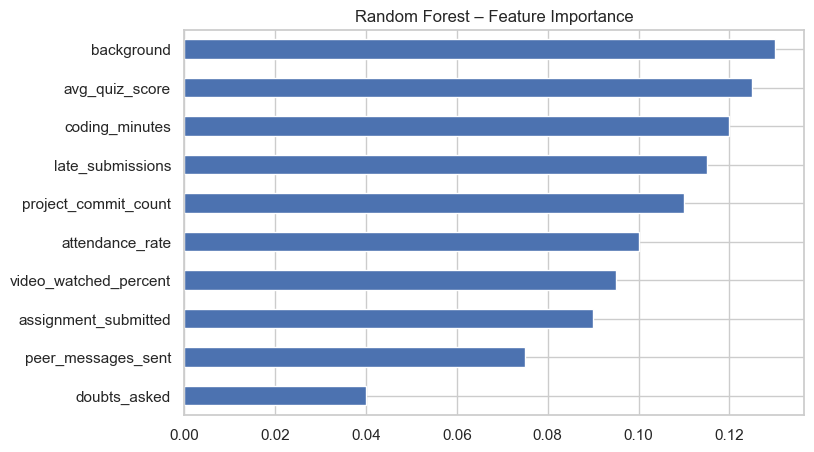

In [16]:
plt.figure(figsize=(8,5))
rf_imp.plot(kind="barh")
plt.title("Random Forest – Feature Importance")
plt.show()


# FINAL — Put it together (System View)

## 13) One student, three views (why?)

- `cluster` → what type of student?
- `dropout_risk_lr` → explainable risk score
- `dropout_risk_rf` → stronger risk score for messy patterns

This is what “intelligence system” looks like.


In [17]:
df[[
    "student_id",
    "cluster",
    "dropout_risk_lr",
    "dropout_risk_rf",
    "dropout"
]].sort_values("dropout_risk_rf", ascending=False).head(12)


,student_id,cluster,dropout_risk_lr,dropout_risk_rf,dropout
1,2,0,0.999992,1.00,1
4,5,0,0.999999,1.00,1
37,38,0,0.999945,1.00,1
34,35,0,0.999997,1.00,1
25,26,0,0.999988,1.00,1
21,22,0,0.999998,1.00,1
14,15,0,1.000000,1.00,1
11,12,0,0.999987,1.00,1
28,29,0,1.000000,1.00,1
31,32,0,0.996918,0.99,1


## 14) Simple action rules (optional)

Now we simulate a *real* intervention policy:

- High risk + at-risk cluster → call immediately
- Medium risk + social cluster → accountability buddy
- High risk + silent grinders → check-in only (they might be fine)


In [18]:
def recommend_action(cluster, risk):
    # You can rename clusters later after you inspect cluster_profile
    if risk >= 0.75 and cluster in [2, 3]:
        return "CALL (high risk)"
    if risk >= 0.60 and cluster == 1:
        return "ACCOUNTABILITY BUDDY"
    if risk >= 0.75 and cluster == 0:
        return "CHECK-IN (silent grinder)"
    if risk >= 0.60:
        return "FOLLOW-UP MESSAGE"
    return "NO ACTION"

df["action"] = df.apply(lambda r: recommend_action(r["cluster"], r["dropout_risk_rf"]), axis=1)
df[["student_id", "cluster", "dropout_risk_rf", "action"]].sort_values("dropout_risk_rf", ascending=False).head(15)


,student_id,cluster,dropout_risk_rf,action
1,2,0,1.000,CHECK-IN (silent grinder)
4,5,0,1.000,CHECK-IN (silent grinder)
37,38,0,1.000,CHECK-IN (silent grinder)
34,35,0,1.000,CHECK-IN (silent grinder)
25,26,0,1.000,CHECK-IN (silent grinder)
21,22,0,1.000,CHECK-IN (silent grinder)
14,15,0,1.000,CHECK-IN (silent grinder)
11,12,0,1.000,CHECK-IN (silent grinder)
28,29,0,1.000,CHECK-IN (silent grinder)
31,32,0,0.990,CHECK-IN (silent grinder)


### Final takeaway

> **Machine learning is not picking the best algorithm.  
> Machine learning is asking the right question.**
